In [ ]:
import pandas as pd
from datetime import datetime
#The original idea was to use interest as the new added feature but i realized it didnt realy change that much and forgot to switch to using exchange
#so interest means exchange in the context of this code

## Read training and test datasets

In [ ]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime
 
    return df

In [124]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')
df_train2 = read_data('data/train_interest.csv')
df_train3 = read_data('data/merged_data.csv')
df_train4 = read_data('data/updated_file.csv')
df_test2 = read_data('data/merged_data_test.csv')
df_test3 = read_data('data/updated_merged_test_data.csv')

len(df_train), len(df_test), len(df_train2), len(df_train3), len(df_test2)

(986, 244, 1041, 985, 243)

In [125]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [126]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


In [127]:
df_train2

,Date,DEXKOUS
0,2019-01-02,1119.11
1,2019-01-03,1124.64
2,2019-01-04,1116.73
3,2019-01-07,1117.50
4,2019-01-08,1122.93
...,...,...
1036,2022-12-22,1275.68
1037,2022-12-23,1280.02
1038,2022-12-26,NaN
1039,2022-12-27,1271.00


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [128]:
# GOOD LUCK
import matplotlib.pyplot as plt

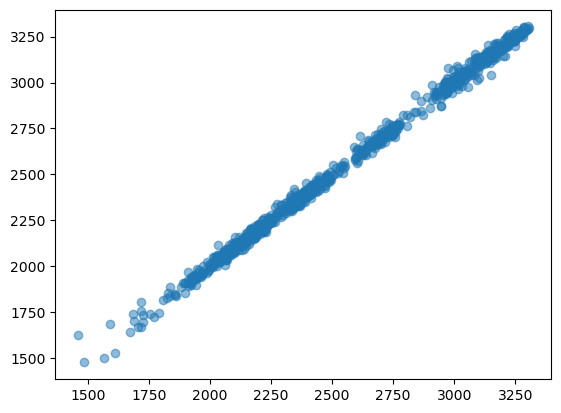

In [129]:
x = df_train['Close'].values
y = df_train['Open'].values

plt.scatter(x, y, alpha=0.5)



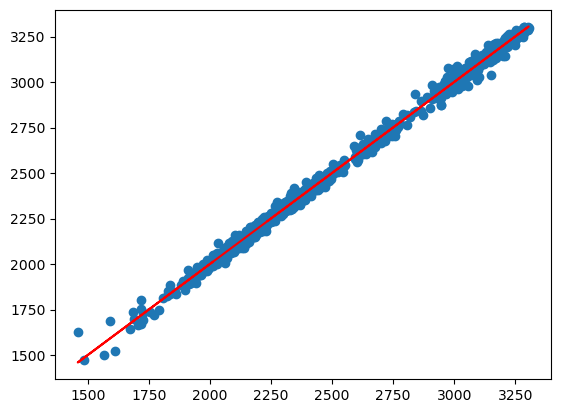

0.9984667470094531


In [130]:
from scipy import stats

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel, color='red')
plt.show()
print(r)

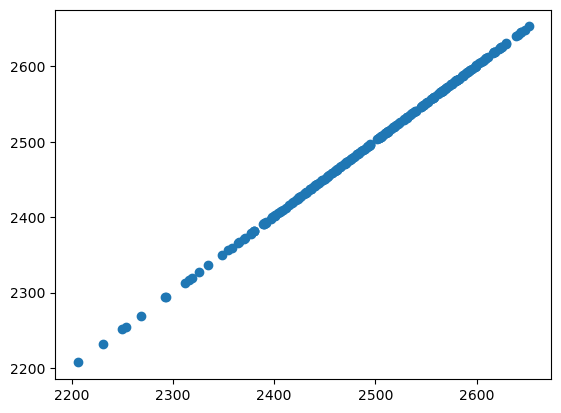

In [131]:
x1 = df_test['Open'].values
predict = myfunc(x1)
plt.scatter(x1, predict)
plt.show()

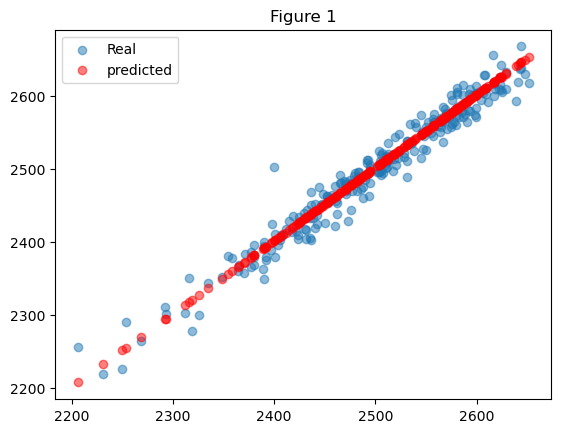

Mean Squared Error: 328.92


In [132]:
from sklearn.metrics import mean_squared_error
y1 = df_test['Close'].values
plt.scatter(x1, y1, alpha=0.5, label='Real')
plt.scatter(x1, predict, color = 'red', alpha=0.5, label='predicted')
plt.title('Figure 1')
plt.legend()
plt.show()
mse1 = mean_squared_error(y1, predict)
print(f"Mean Squared Error: {mse1:.2f}")

In [133]:
import numpy as np

mse = np.mean((y1 - predict) ** 2)
print(f"Mean Squared Error: {mse:.2f}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")


Mean Squared Error: 328.92
Root Mean Squared Error: 18.14


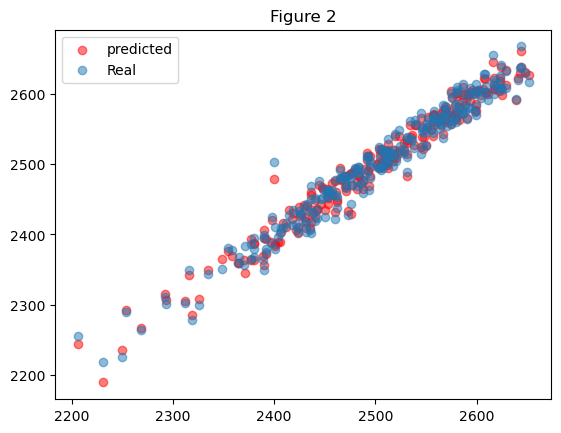

Mean Squared Error: 56.66


In [134]:
import pandas as pd
from sklearn import linear_model

x = df_train[['Open', 'High', 'Low', 'Volume']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[['Open', 'High', 'Low', 'Volume']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5, label='predicted')
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5, label='Real')
plt.title('Figure 2')
plt.legend()
plt.show()

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")    
 

Mean Squared Error: 56.51


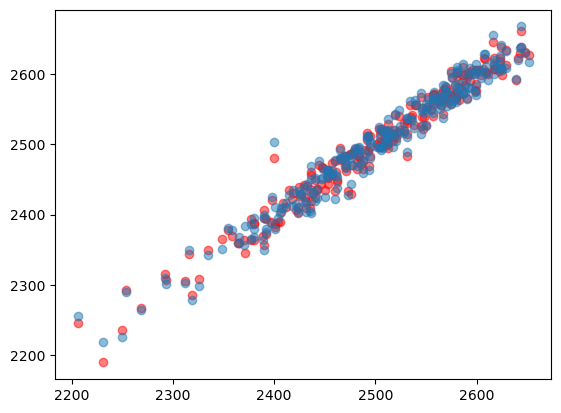

In [135]:
x = df_train[['Open', 'High', 'Low']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[['Open', 'High', 'Low']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

Mean Squared Error: 144.04


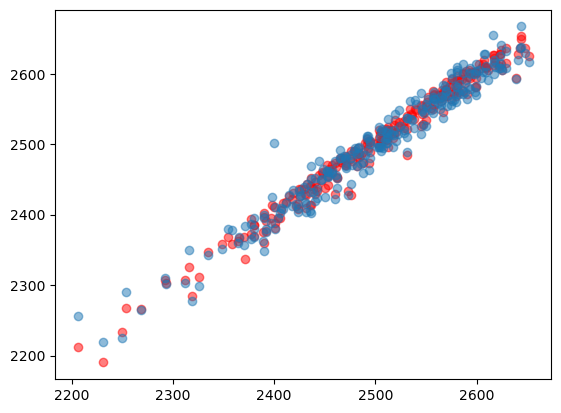

In [136]:
x = df_train[['Open',  'Low', 'Volume']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[['Open',  'Low', 'Volume']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

Mean Squared Error: 109.55


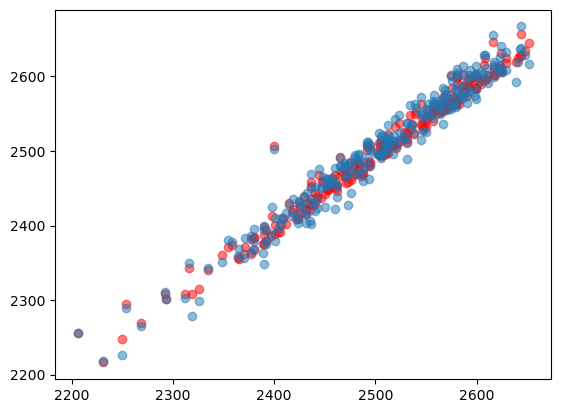

In [137]:
x = df_train[['Open', 'High', 'Volume']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[['Open', 'High', 'Volume']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

Mean Squared Error: 120.29


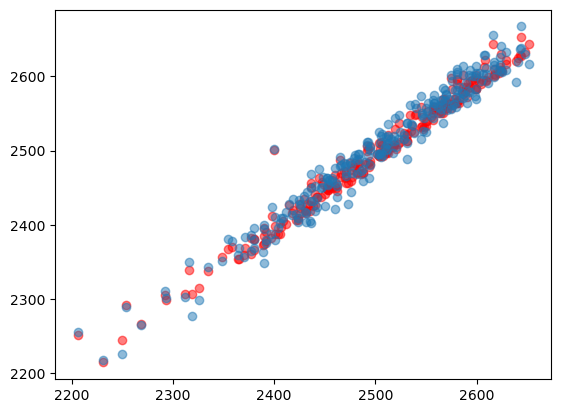

In [138]:
x = df_train[['Open', 'High']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[['Open', 'High']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

Mean Squared Error: 106.71


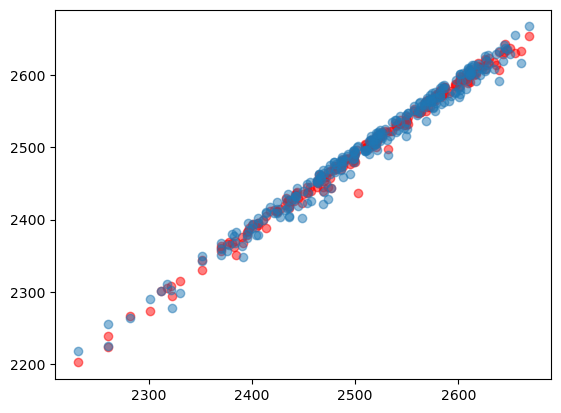

In [139]:
x = df_train[[ 'High', 'Low', 'Volume']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[[ 'High', 'Low', 'Volume']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

Mean Squared Error: 106.71


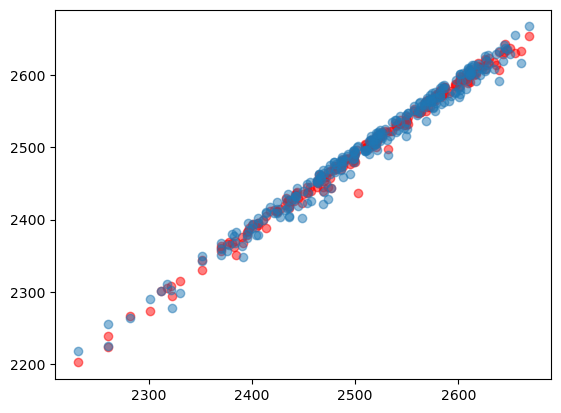

In [140]:
x = df_train[[ 'High', 'Low', 'Volume']].values
y = df_train['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test[[ 'High', 'Low', 'Volume']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")  

[Text(0.5354045807793345, 0.9736842105263158, 'Low <= 2549.905\nsquared_error = 185095.911\nsamples = 986\nvalue = 2489.983'),
 Text(0.298844771599533, 0.9210526315789473, 'Low <= 2210.84\nsquared_error = 33315.5\nsamples = 607\nvalue = 2186.761'),
 Text(0.11264138207822534, 0.868421052631579, 'Low <= 1982.675\nsquared_error = 16633.218\nsamples = 373\nvalue = 2073.729'),
 Text(0.023460303561004085, 0.8157894736842105, 'High <= 1824.14\nsquared_error = 14990.764\nsamples = 75\nvalue = 1867.281'),
 Text(0.007472270869819031, 0.7631578947368421, 'High <= 1700.795\nsquared_error = 8674.773\nsamples = 17\nvalue = 1669.076'),
 Text(0.0037361354349095153, 0.7105263157894737, 'Low <= 1462.445\nsquared_error = 3656.814\nsamples = 5\nvalue = 1541.484'),
 Text(0.0018680677174547577, 0.6578947368421053, 'High <= 1571.42\nsquared_error = 154.007\nsamples = 2\nvalue = 1470.05'),
 Text(0.0009340338587273788, 0.6052631578947368, 'squared_error = 0.0\nsamples = 1\nvalue = 1482.46'),
 Text(0.0028021015

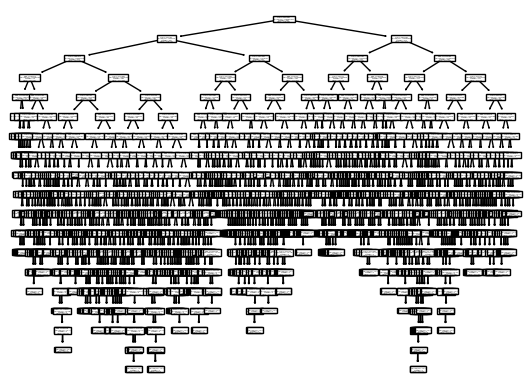

In [141]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
features = ['Open', 'High', 'Low', 'Volume']
x = df_train[features].values
y = df_train['Close'].values

dtree = DecisionTreeRegressor()
dtree = dtree.fit(x, y)

tree.plot_tree(dtree, feature_names=features)

In [142]:
testX = df_test[features].values
treepredict = dtree.predict(testX)
mse = mean_squared_error(df_test['Close'].values, treepredict)
print("Mean Squared Error:", mse)

Mean Squared Error: 321.0368840362205


In [143]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
X_train = df_train[['Open', 'High', 'Low', 'Close', 'Volume']].values
y_train = df_train['Close'].shift(-1).dropna().values

X_train = X_train[:-1]

X_test = df_test[['Open', 'High', 'Low', 'Close', 'Volume']].values
y_test = df_test['Close'].shift(-1).dropna().values
X_test = X_test[:-1]
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest MSE:", mse)
print("R² Score:", r2)

Random Forest MSE: 647.772216243387
R² Score: 0.9145865981348364


In [144]:
#import pandas as pd

# used to merge the two datasets
#df1 = pd.read_csv('data/kospi_train.csv', names=['Date', 'Open', 'Low', 'High', 'Close', 'Volume'], parse_dates=['Date'])
#df2 = pd.read_csv('data/DEXKOUS.csv', names=['Date', 'DEXKOUS'], parse_dates=['Date'])
#merged_df = pd.merge(df1, df2, on='Date', how='inner')  # use 'outer' to keep all dates
#merged_df.to_csv('merged_data.csv', index=False)

In [145]:

df_train3 = df_train3.sort_values(by='Date')
df_train3['Interest'] = df_train3['Interest'].interpolate(method='linear')
df_train3['Interest'] = df_train3['Interest'].fillna(method='bfill').fillna(method='ffill')
df_train3['Interest'] = df_train3['Interest'].apply(lambda x: (x + df_train3['Interest'].shift(-1)) / 2 if pd.isna(x) else x)

C:\Users\thoma\AppData\Local\Temp\ipykernel_27400\1138627695.py:2: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_train3['Interest'] = df_train3['Interest'].interpolate(method='linear')
C:\Users\thoma\AppData\Local\Temp\ipykernel_27400\1138627695.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_train3['Interest'] = df_train3['Interest'].fillna(method='bfill').fillna(method='ffill')


In [146]:
# used to merge the two datasets
#import pandas as pd
#df1 = pd.read_csv('data/kospi_test.csv', names=['Date', 'Open', 'Low', 'High', 'Close', 'Volume'], parse_dates=['Date'])
#df2 = pd.read_csv('data/Interest_test.csv', names=['Date', 'Interest'], parse_dates=['Date'])
#merged_df = pd.merge(df1, df2, on='Date', how='inner')  # use 'outer' to keep all dates
#merged_df.to_csv('merged_data_test.csv', index=False)

In [147]:

# replace NaN
#col_to_fill = ['Interest']

#for col in col_to_fill:
    #for i in range(len(df_train3[col])):
       #if pd.isna(df_train3.loc[i, col]):
            #prev_val = df_train3.loc[i - 1, col] if i > 0 else df_train3.loc[0, col] if len(df_train3[col]) > 0 else None
            #next_val = df_train3.loc[i + 1, col] if i < len(df_train3[col]) - 1 else df_train3.loc[len(df_train3[col]) - 1, col] if len(df_train3[col]) > 0 else None
            #if prev_val is not None and next_val is not None:
                #avg_val = (prev_val + next_val) / 2
                # Fill the NaN value with the calculated average
                #df_train3.loc[i, col] = avg_val
            #else:
                #df_train3.loc[i, col] = None  # Or any other default value you prefer


#df_train3.to_csv('updated_file.csv', index=False)


In [148]:
#replace NaN in the test dataset
col_to_fill = ['Interest']
for col in col_to_fill:
    for i in range(len(df_test2[col])):
       if pd.isna(df_test2.loc[i, col]):
            prev_val = df_test2.loc[i - 1, col] if i > 0 else df_test2.loc[0, col] if len(df_test2[col]) > 0 else None
            next_val = df_test2.loc[i + 1, col] if i < len(df_test2[col]) - 1 else df_test2.loc[len(df_test2[col]) - 1, col] if len(df_test2[col]) > 0 else None
            if prev_val is not None and next_val is not None:
                avg_val = (prev_val + next_val) / 2
                df_test2.loc[i, col] = avg_val
            else:
                df_test2.loc[i, col] = None

df_test2.to_csv('updated_merged_test_data.csv', index=False)

Mean Squared Error: 56.39


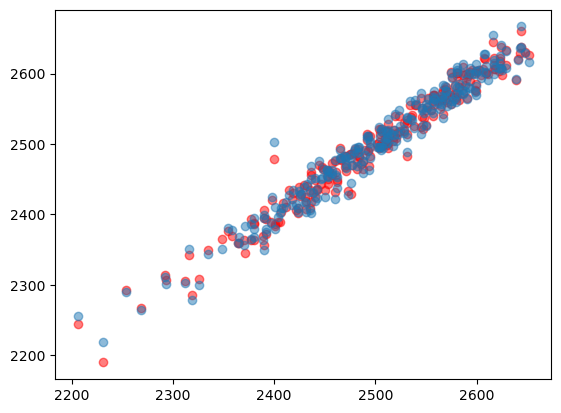

In [149]:
x = df_train4[['Open', 'High', 'Low','Volume',  'Interest']].values
y = df_train4['Close'].values


reg = linear_model.LinearRegression()
reg.fit(x, y)

testX = df_test3[['Open', 'High', 'Low', 'Volume',  'Interest']].values
predictions = reg.predict(testX)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test3['Close'].values, alpha=0.5)
testX = df_test3[['Open', 'High', 'Low', 'Interest']].values
mse1 = mean_squared_error(df_test3['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}") 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.464e+05
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:51:15   Log-Likelihood:                -3637.3
No. Observations:                 986   AIC:                             7283.
Df Residuals:                     982   BIC:                             7302.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3326      1.825      1.826      0.0

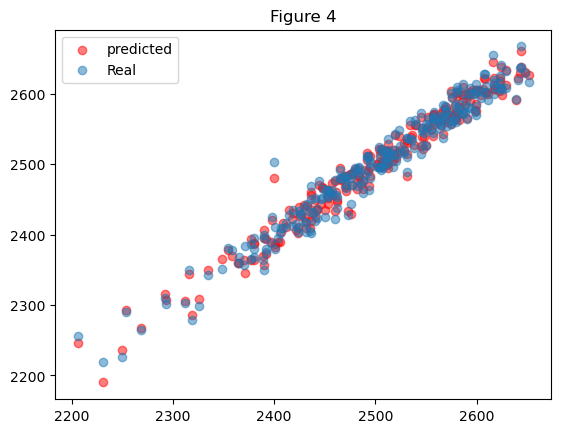

Mean Squared Error: 56.51


In [150]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


x = df_train[['Open', 'High', 'Low']].values
y = df_train['Close'].values

x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
print(model.summary())

testX = df_test[['Open', 'High', 'Low']].values
testX_with_const = sm.add_constant(testX)
predictions = model.predict(testX_with_const)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5, label='predicted')
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5, label='Real')
plt.title('Figure 4')
plt.legend()
plt.show()

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.848e+05
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:51:15   Log-Likelihood:                -3636.8
No. Observations:                 986   AIC:                             7284.
Df Residuals:                     981   BIC:                             7308.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6168      1.849      1.956      0.0

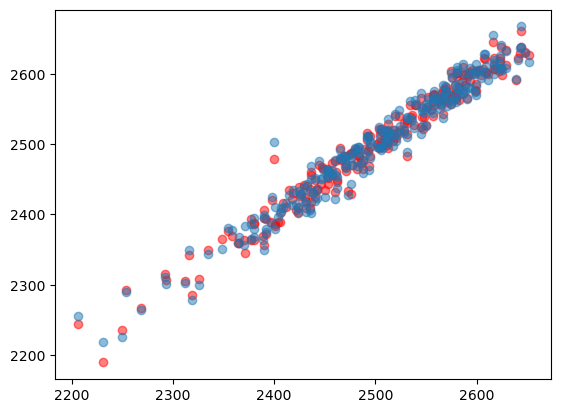

In [151]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

x = df_train[['Open', 'High', 'Low', 'Volume']].values
y = df_train['Close'].values

x_with_const = sm.add_constant(x)

model = sm.OLS(y, x_with_const).fit()

print(model.summary())

testX = df_test[['Open', 'High', 'Low', 'Volume']].values
testX_with_const = sm.add_constant(testX)
predictions = model.predict(testX_with_const)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5)
plt.scatter(testX[:, 0], df_test['Close'].values, alpha=0.5)

mse1 = mean_squared_error(df_test['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.847e+05
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:51:15   Log-Likelihood:                -3633.0
No. Observations:                 985   AIC:                             7276.
Df Residuals:                     980   BIC:                             7300.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0875      6.099      1.326      0.1

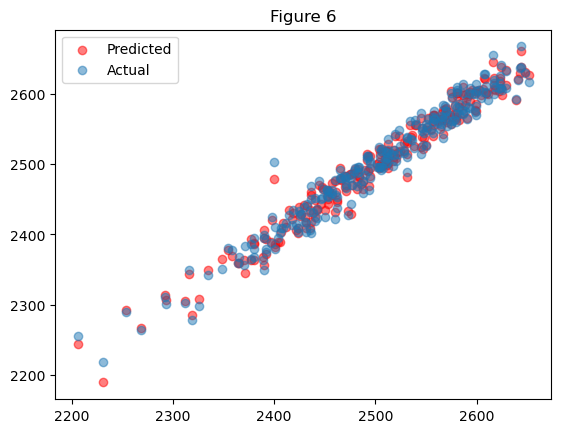

Mean Squared Error: 56.21


In [152]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

x = df_train4[['Open', 'High', 'Low', 'Interest']].values
y = df_train4['Close'].values
x_with_const = sm.add_constant(x)
model = sm.OLS(y, x_with_const).fit()
print(model.summary())
testX = df_test3[['Open', 'High', 'Low', 'Interest']].values
testX_with_const = sm.add_constant(testX)
predictions = model.predict(testX_with_const)
plt.scatter(testX[:, 0], predictions, color='red', alpha=0.5, label='Predicted')
plt.scatter(testX[:, 0], df_test3['Close'].values, alpha=0.5, label='Actual')
plt.title('Figure 6')
plt.legend()
plt.show()
mse1 = mean_squared_error(df_test3['Close'].values, predictions)
print(f"Mean Squared Error: {mse1:.2f}")
